In [2]:
library(forecast)
library(tseries)
library(ggplot2)
library(zoo)
library(astsa)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric



Attaching package: 'astsa'


The following object is masked from 'package:forecast':

    gas




In [4]:
ts_data

A Time Series:
 [1] 1.3862944 1.6863990 1.0986123 2.4595888 2.9123507 2.6173958 2.6672282
 [8] 2.6741486 2.5176965 1.8718022 1.6094379 1.3862944 1.3083328 1.3609766
[15] 1.6863990 1.4586150 0.5306283 1.0296194 2.0794415 1.6292405 1.7749524
[22] 1.9021075 1.5260563 1.4586150 2.0668628 2.1400662 1.6292405 1.5260563
[29] 0.3364722 0.3364722 1.6486586 2.4595888 1.9021075 0.8754687 1.6094379
[36] 1.1631508 0.5877867 1.1939225 1.4350845 1.1631508 2.1633230 2.7663191
[43] 3.1612467 3.2148678 3.0773123 3.0007198 2.8273136 2.6602595 2.9444390
[50] 2.8449094 2.6810215 2.2925348 1.5475625 0.6418539 0.1823216 0.6418539
[57] 1.3609766 1.3609766 1.3350011 1.7749524 1.6677068 1.1939225 1.0986123
[64] 1.0647107 1.7047481 1.4816045 1.4109870 1.4586150 1.9169226 1.7047481
[71] 1.7047481 1.9021075 1.7047481 1.7404662 1.6486586 1.5040774 1.3350011
[78] 1.3350011 1.2809338 1.2527630 1.5892352 1.7749524 1.7227666 1.5892352
[85] 1.7227666 2.1400662 2.0412203 1.9600948 1.8082888 1.7578579 1.9600948
[92] 2.0281482 2.2721259 2.2617631 2.0149030 1.9740810 1.9459101 1.8245493
[99] 1.7047481

In [3]:
# Carregar pacote e dados
data(NelPlo)
# Extrair a série unemp como ts
ts_data <- NelPlo[, "unemp"]   # Note a vírgula e as aspas

dados_sem_na <- na.omit(as.numeric(ts_data))
novo_start <- start(ts_data) + c(0, (min(which(!is.na(ts_data)))-1) / frequency(ts_data))
ts_limpa <- ts(dados_sem_na, start = novo_start, frequency = frequency(ts_data))

ts_data <- ts_limpa

# Agora funciona
cat("Classe    :", class(ts_data), "\n")
cat("Início    :", start(ts_data), "\n")
cat("Fim       :", end(ts_data), "\n")
cat("Frequência:", frequency(ts_data), "\n")
cat("N obs     :", length(ts_data), "\n")
print(summary(ts_data))

Classe    : ts 
Início    : 1890 1 
Fim       : 1988 1 
Frequência: 1 
N obs     : 99 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1823  1.3736  1.7047  1.7514  2.0540  3.2149 


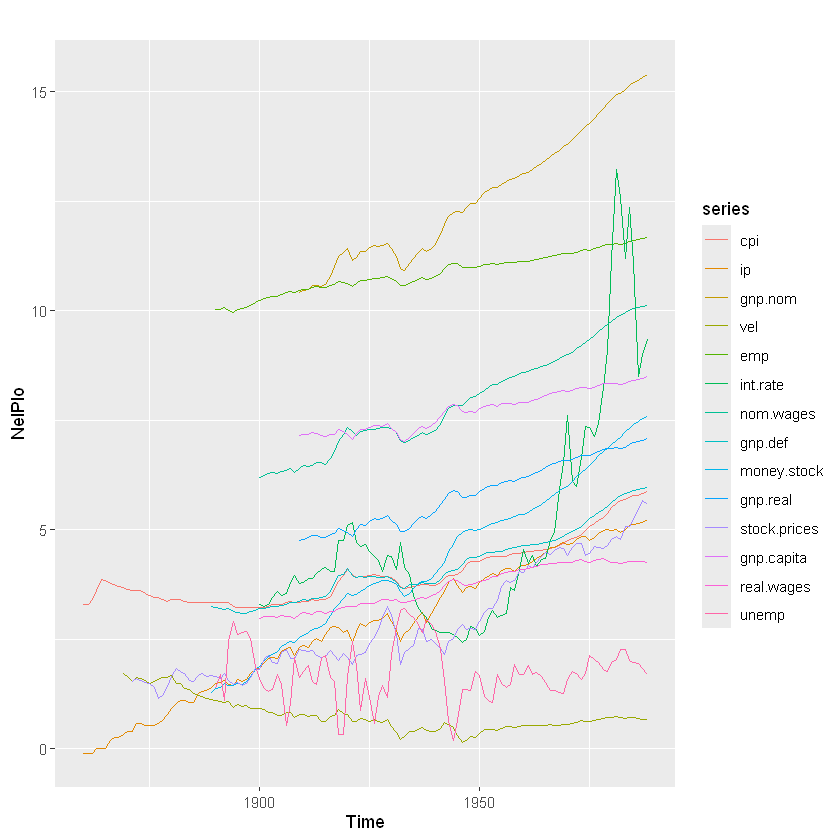

In [9]:
autoplot(NelPlo)

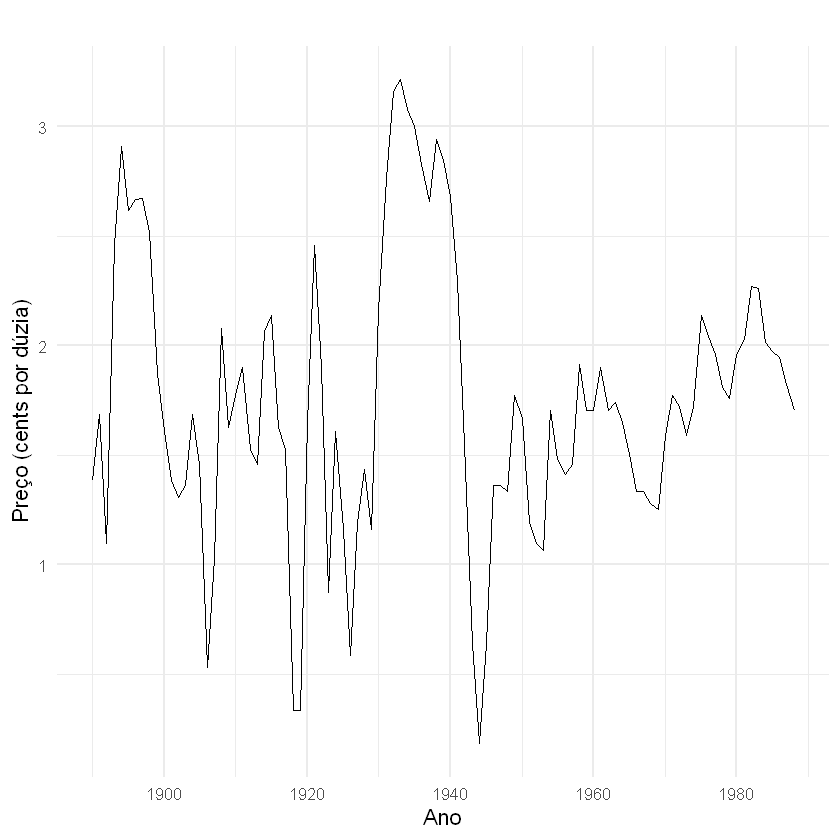

In [10]:
autoplot(ts_data) +
  labs(
    title = "",
    x     = "Ano",
    y     = "Preço (cents por dúzia)"
  ) +
  theme_minimal(base_size = 13)

Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`)."


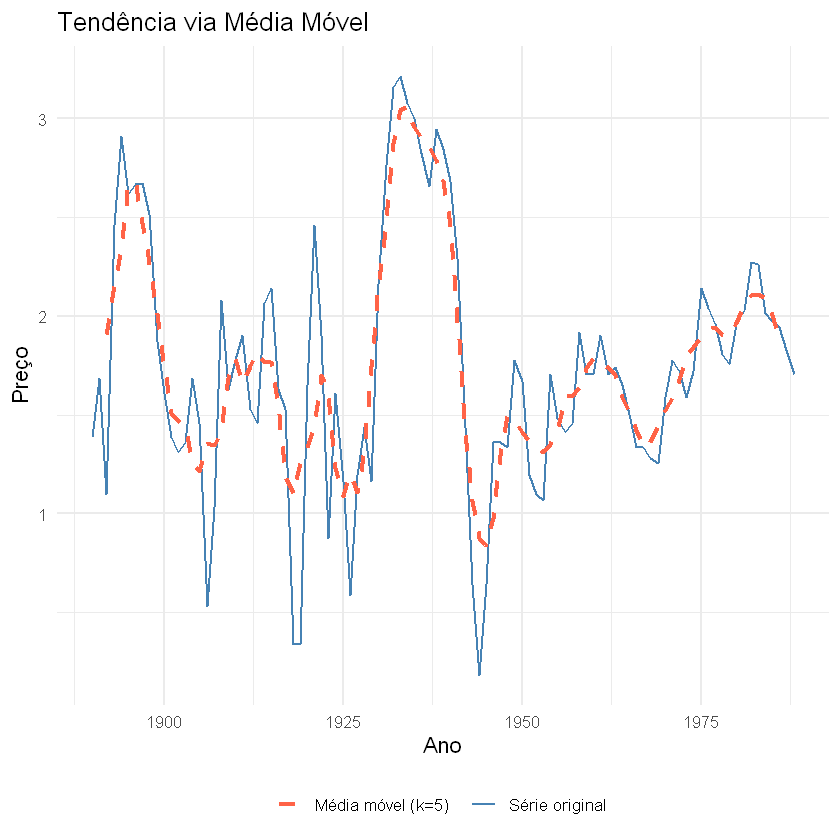

In [11]:
# Média móvel de ordem 5 para suavizar a tendência
library(zoo)
tendencia <- rollmean(ts_data, k = 5, fill = NA)

df_plot <- data.frame(
  ano       = as.numeric(time(ts_data)),
  original  = as.numeric(ts_data),
  tendencia = as.numeric(tendencia)
)

ggplot(df_plot, aes(x = ano)) +
  geom_line(aes(y = original,  color = "Série original"), linewidth = 0.8) +
  geom_line(aes(y = tendencia, color = "Média móvel (k=5)"), linewidth = 1.2, linetype = "dashed") +
  scale_color_manual(values = c("Série original" = "steelblue", "Média móvel (k=5)" = "tomato")) +
  labs(title = "Tendência via Média Móvel", x = "Ano", y = "Preço", color = NULL) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

In [12]:
cat("=== Teste ADF — Série Original ===\n")
print(adf.test(ts_data))

=== Teste ADF — Série Original ===

	Augmented Dickey-Fuller Test

data:  ts_data
Dickey-Fuller = -3.4183, Lag order = 4, p-value = 0.0556
alternative hypothesis: stationary



Diferenças aplicadas: 0 


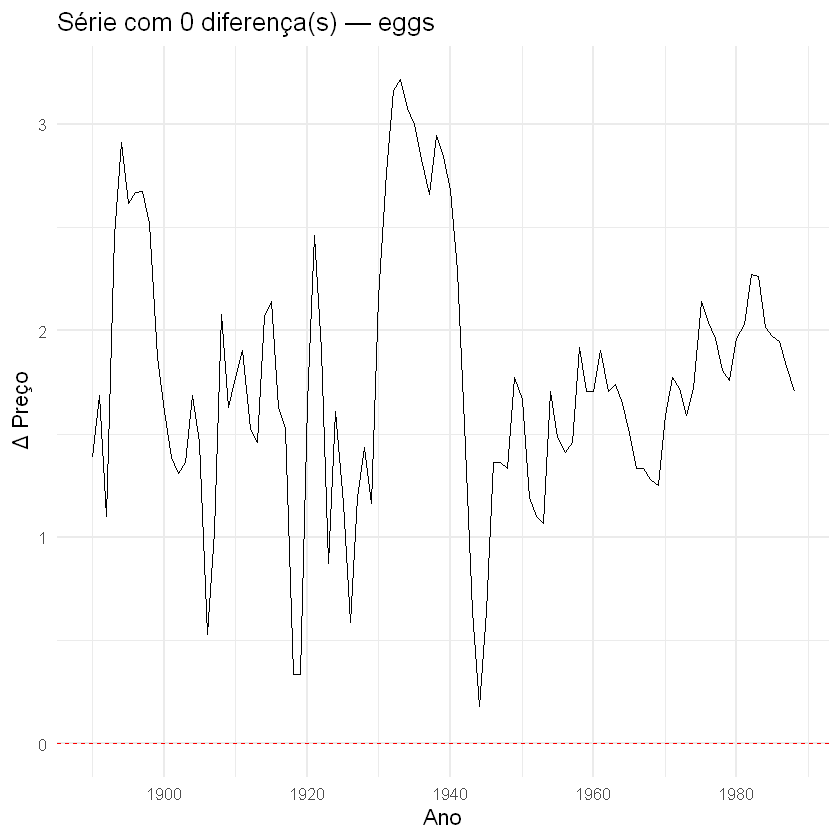

In [13]:
# Aplicando diferenciação simples
d <- ndiffs(ts_data)   # número de diferenças indicado

ts_diff <- ts_data
for (i in seq_len(d)) ts_diff <- diff(ts_diff)

cat("Diferenças aplicadas:", d, "\n")

autoplot(ts_diff) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = paste0("Série com ", d, " diferença(s) — eggs"),
    x = "Ano", y = "Δ Preço"
  ) +
  theme_minimal(base_size = 13)

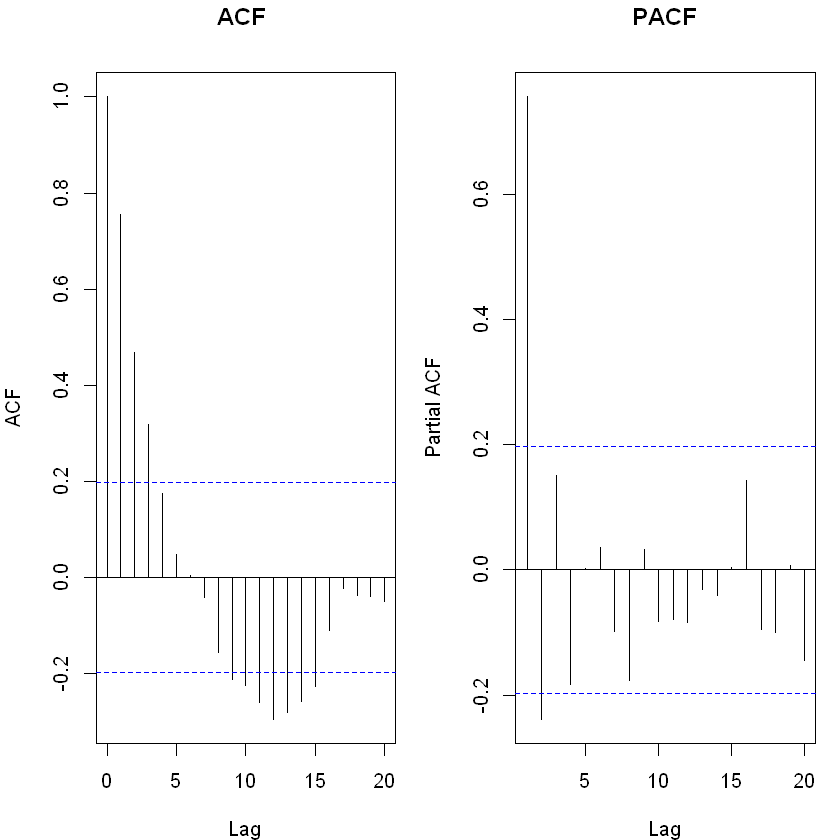

In [14]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
acf(ts_data,  lag.max = 20, main = "ACF ")
pacf(ts_data, lag.max = 20, main = "PACF")

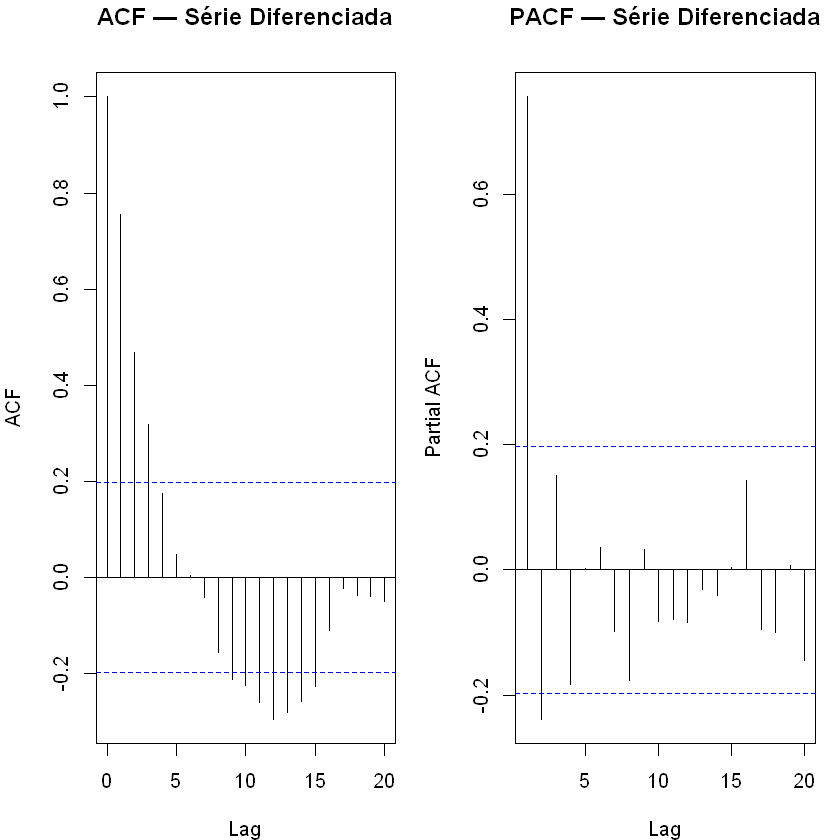

In [15]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
acf(ts_diff,  lag.max = 20, main = "ACF — Série Diferenciada")
pacf(ts_diff, lag.max = 20, main = "PACF — Série Diferenciada")

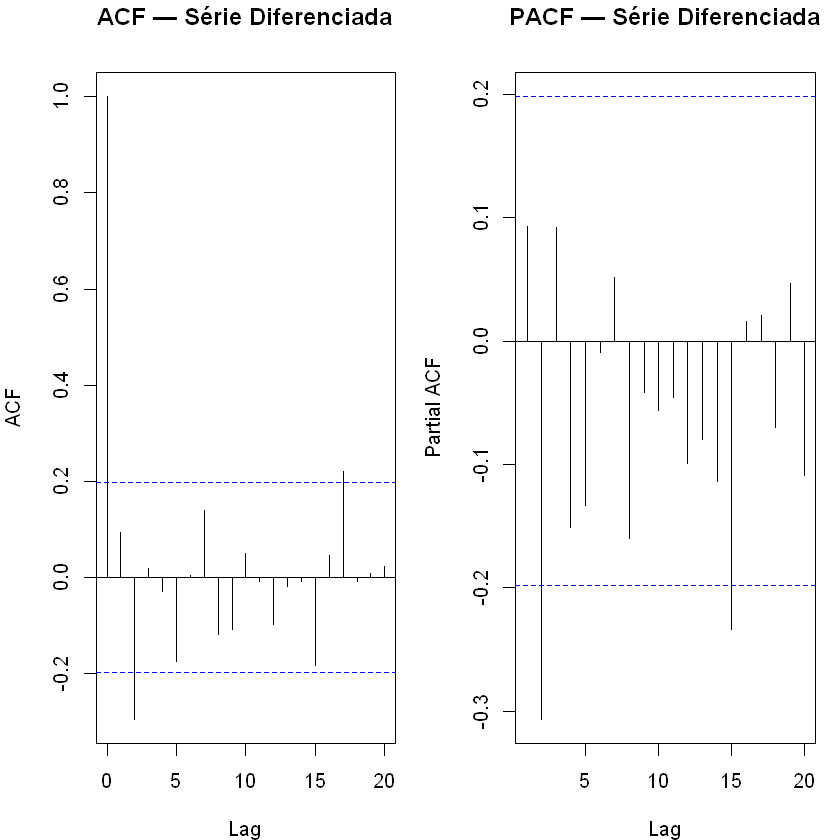

In [16]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
acf(diff(ts_diff),  lag.max = 20, main = "ACF — Série Diferenciada")
pacf(diff(ts_diff), lag.max = 20, main = "PACF — Série Diferenciada")

In [17]:
# Seleção automática
modelo_auto <- auto.arima(
  ts_data,
  stepwise      = FALSE,
  approximation = FALSE,
  trace         = TRUE
)

cat("\n=== Modelo selecionado automaticamente ===\n")
summary(modelo_auto)


 ARIMA(0,0,0) with zero mean     : 406.1704
 ARIMA(0,0,0) with non-zero mean : 195.0655
 ARIMA(0,0,1) with zero mean     : 291.0191
 ARIMA(0,0,1) with non-zero mean : 121.2757
 ARIMA(0,0,2) with zero mean     : 225.2638
 ARIMA(0,0,2) with non-zero mean : 111.3403
 ARIMA(0,0,3) with zero mean     : 198.2992
 ARIMA(0,0,3) with non-zero mean : 109.7018
 ARIMA(0,0,4) with zero mean     : 177.579
 ARIMA(0,0,4) with non-zero mean : 106.6953
 ARIMA(0,0,5) with zero mean     : 160.7567
 ARIMA(0,0,5) with non-zero mean : 108.1997
 ARIMA(1,0,0) with zero mean     : 125.7396
 ARIMA(1,0,0) with non-zero mean : 113.8767
 ARIMA(1,0,1) with zero mean     : 124.6633
 ARIMA(1,0,1) with non-zero mean : 104.858
 ARIMA(1,0,2) with zero mean     : 116.5239
 ARIMA(1,0,2) with non-zero mean : 105.4956
 ARIMA(1,0,3) with zero mean     : 118.6989
 ARIMA(1,0,3) with non-zero mean : 107.0891
 ARIMA(1,0,4) with zero mean     : Inf
 ARIMA(1,0,4) with non-zero mean : 108.5232
 ARIMA(2,0,0) with zero mean     : 126

Series: ts_data 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
         ar1     ma1    mean
      0.5269  0.5546  1.7374
s.e.  0.1098  0.1311  0.1274

sigma^2 = 0.158:  log likelihood = -48.22
AIC=104.43   AICc=104.86   BIC=114.81

Training set error measures:
                      ME      RMSE       MAE       MPE     MAPE      MASE
Training set 0.004466967 0.3914123 0.2898267 -10.81206 25.33637 0.9151758
                    ACF1
Training set -0.04648874

In [18]:
# Extraindo a ordem do modelo automático para referência
ord <- arimaorder(modelo_auto)
cat(sprintf("Modelo auto: ARIMA(%d,%d,%d)\n", ord[1], ord[2], ord[3]))
cat(sprintf("AIC: %.2f | BIC: %.2f\n", AIC(modelo_auto), BIC(modelo_auto)))

Modelo auto: ARIMA(1,0,1)
AIC: 104.43 | BIC: 114.81


In [19]:
modelo_final <- modelo_auto

ord_f <- arimaorder(modelo_final)
cat(sprintf("Modelo final escolhido: ARIMA(%d,%d,%d)\n", ord_f[1], ord_f[2], ord_f[3]))

Modelo final escolhido: ARIMA(1,0,1)


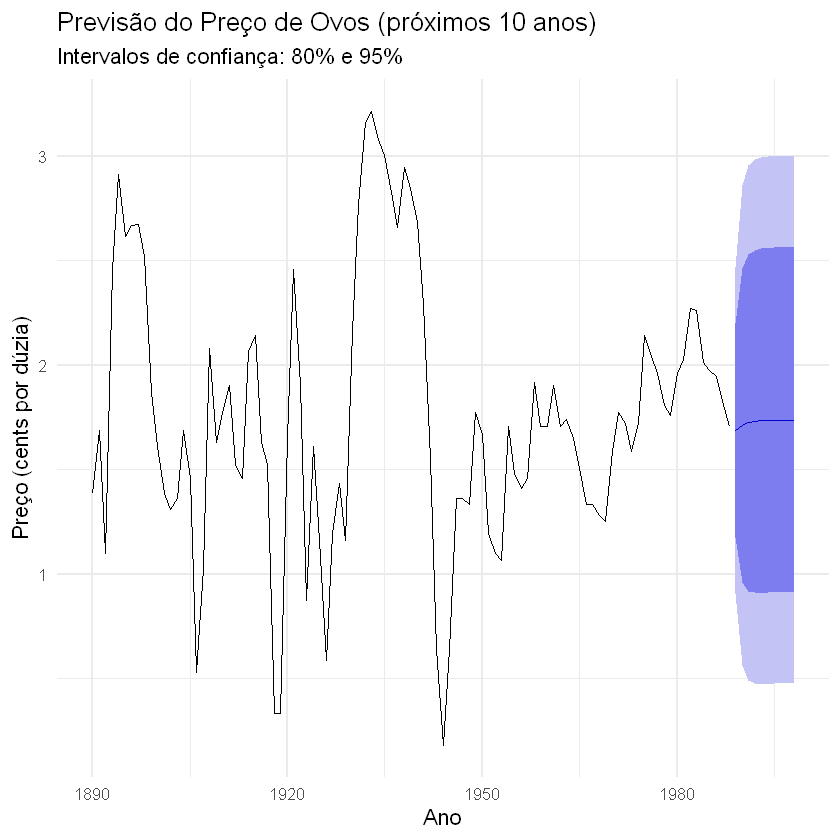

In [20]:
h <- 10  # horizonte: 10 anos

prev <- forecast(modelo_final, h = h, level = c(80, 95))

autoplot(prev) +
  labs(
    title    = "Previsão do Preço de Ovos (próximos 10 anos)",
    subtitle = "Intervalos de confiança: 80% e 95%",
    x        = "Ano",
    y        = "Preço (cents por dúzia)"
  ) +
  theme_minimal(base_size = 13)

initial  value -0.451191 
iter   2 value -0.816312
iter   3 value -0.918728
iter   4 value -0.929643
iter   5 value -0.932677
iter   6 value -0.934289
iter   7 value -0.934414
iter   8 value -0.934419
iter   9 value -0.934421
iter  10 value -0.934423
iter  11 value -0.934424
iter  12 value -0.934424
iter  12 value -0.934424
iter  12 value -0.934424
final  value -0.934424 
converged
initial  value -0.931355 
iter   2 value -0.931638
iter   3 value -0.931812
iter   4 value -0.931905
iter   5 value -0.931906
iter   6 value -0.931906
iter   7 value -0.931906
iter   7 value -0.931906
iter   7 value -0.931906
final  value -0.931906 
converged
<><><><><><><><><><><><><><>
 
Coefficients: 
      Estimate     SE t.value p.value
ar1     0.5269 0.1098  4.7983   0e+00
ma1     0.5546 0.1311  4.2307   1e-04
xmean   1.7374 0.1274 13.6335   0e+00

sigma^2 estimated as 0.1532036 on 96 degrees of freedom 
 
AIC = 1.054874  AICc = 1.057426  BIC = 1.159727 
 


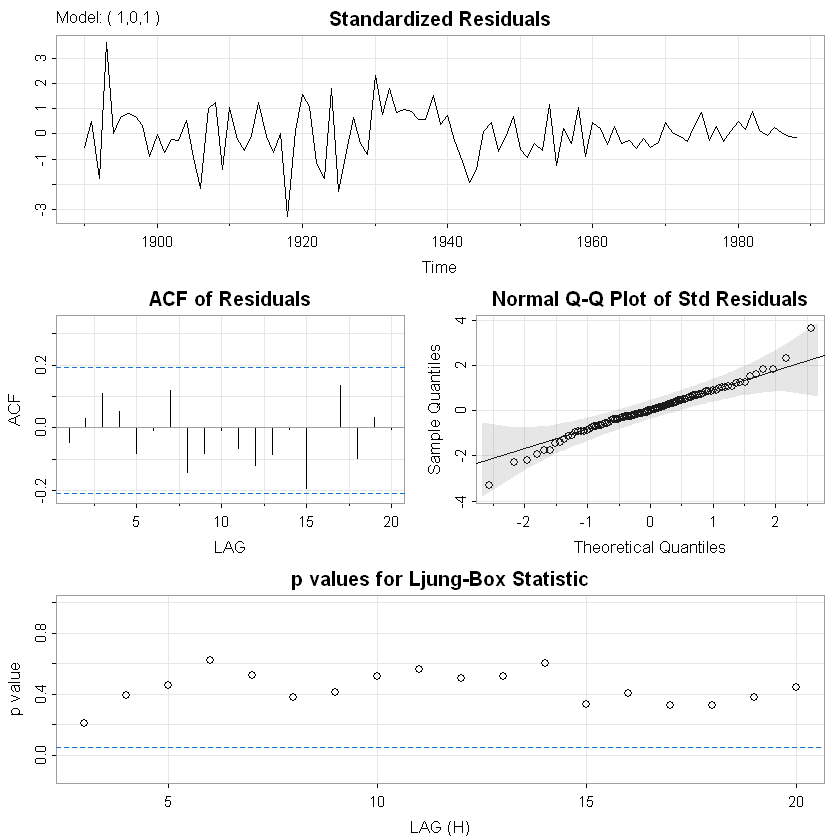

$pred
Time Series:
Start = 1989 
End = 1998 
Frequency = 1 
 [1] 1.713444 1.719970 1.724869 1.728546 1.731306 1.733377 1.734932 1.736099
 [9] 1.736975 1.737632

$se
Time Series:
Start = 1989 
End = 1998 
Frequency = 1 
 [1] 0.4149623 0.5188447 0.5690769 0.5955126 0.6099008 0.6178590 0.6222974
 [8] 0.6247839 0.6261804 0.6269657

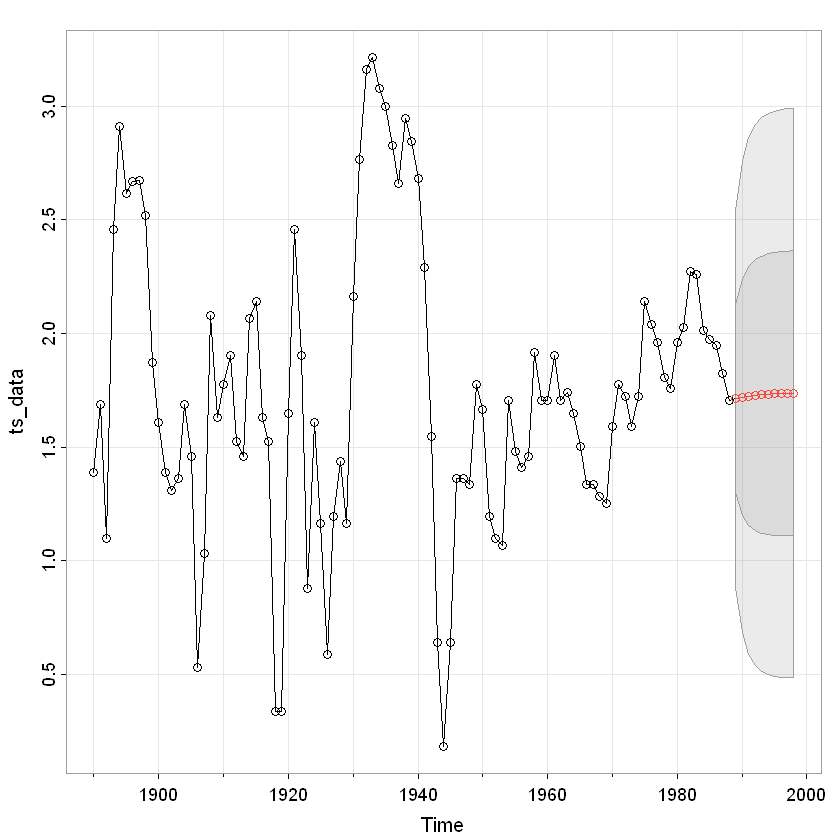

In [24]:
sarima(ts_data,1,0,1)

##################################
#
#
sarima.for(ts_data,10,1,0,0)